# Сравнение Парето-фронтов


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

SEED = 42
notebook_dir = Path("examples") if Path("examples/paper.ipynb").exists() else Path(".")
no_llm_dir = notebook_dir / "nsga_2_without_llm"
prompt_dir = notebook_dir / "nsga_2_llm_prompts"

seed42_front_path = no_llm_dir / f"no_llm_pareto_front_{SEED}.jsonl"
seed42_log_path = no_llm_dir / f"no_llm_optimization_log_{SEED}.jsonl"
prompt_front_files = sorted(
    prompt_dir.glob("prompt_*/prompt_*_pareto_front.jsonl"),
    key=lambda path: int(path.parent.name.rsplit("_", 1)[-1]),
)

if not seed42_front_path.exists():
    raise FileNotFoundError(seed42_front_path)
if not seed42_log_path.exists():
    raise FileNotFoundError(seed42_log_path)
if len(prompt_front_files) != 5:
    raise FileNotFoundError(f"Ожидалось 5 prompt-фронтов в {prompt_dir}, найдено {len(prompt_front_files)}")


def read_jsonl(path):
    df = pd.read_json(path, lines=True)
    for col in ["investor_npv", "land_value_gain", "llm score"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "scenario_id" not in df.columns:
        df.insert(0, "scenario_id", [f"{path.stem}_{i + 1}" for i in range(len(df))])
    return df


seed42_front = read_jsonl(seed42_front_path)
prompt_fronts = {
    int(path.parent.name.rsplit("_", 1)[-1]): read_jsonl(path)
    for path in prompt_front_files
}

print(f"seed {SEED} no-LLM фронт: {len(seed42_front)} решений")
for prompt_id, df in prompt_fronts.items():
    print(f"prompt {prompt_id} LLM фронт: {len(df)} решений")


seed 42 no-LLM фронт: 14 решений
prompt 1 LLM фронт: 20 решений
prompt 2 LLM фронт: 20 решений
prompt 3 LLM фронт: 20 решений
prompt 4 LLM фронт: 20 решений
prompt 5 LLM фронт: 18 решений


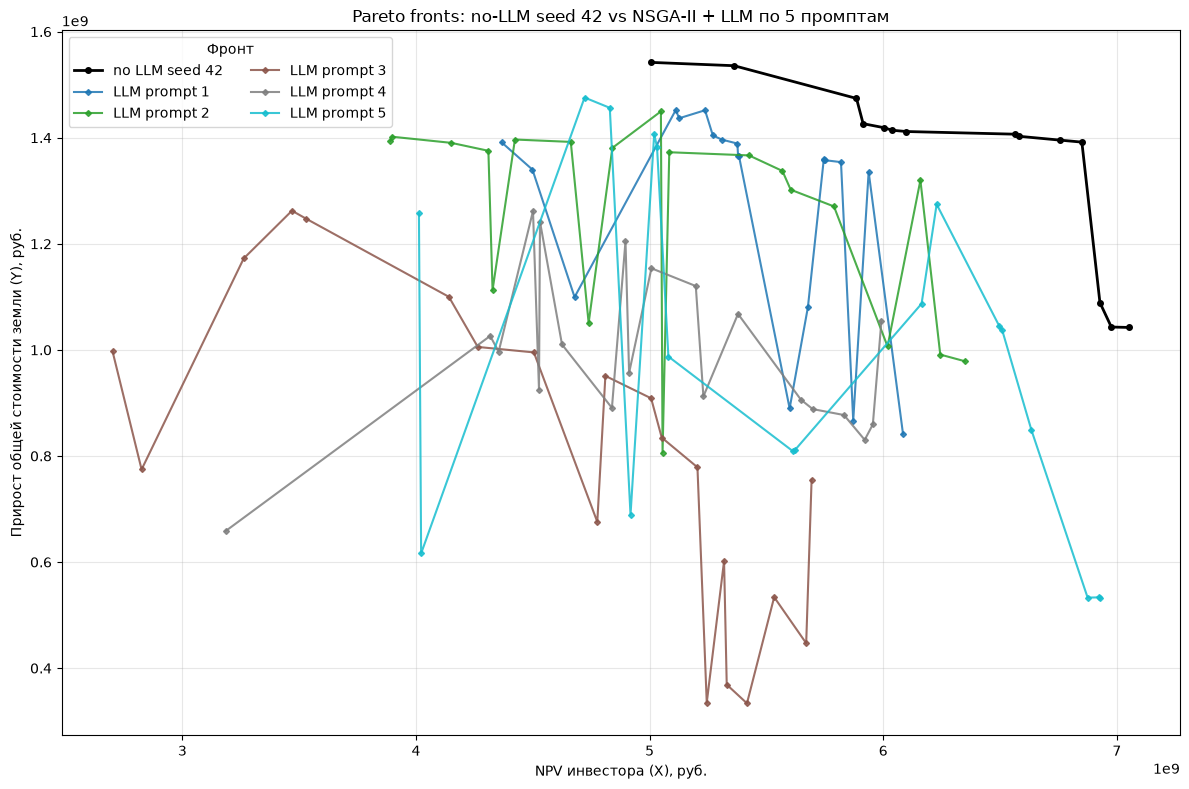

In [12]:
plt.figure(figsize=(12, 8))

base = seed42_front.sort_values("investor_npv")
plt.plot(
    base["investor_npv"],
    base["land_value_gain"],
    marker="o",
    ms=4,
    lw=2.0,
    color="black",
    label=f"no LLM seed {SEED}",
)

cmap = plt.get_cmap("tab10", len(prompt_fronts))
for i, (prompt_id, df) in enumerate(prompt_fronts.items()):
    df = df.sort_values("investor_npv")
    plt.plot(
        df["investor_npv"],
        df["land_value_gain"],
        marker="D",
        ms=3,
        lw=1.5,
        alpha=0.85,
        color=cmap(i),
        label=f"LLM prompt {prompt_id}",
    )

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title(f"Pareto fronts: no-LLM seed {SEED} vs NSGA-II + LLM по 5 промптам")
plt.grid(True, alpha=0.3)
plt.legend(title="Фронт", ncol=2)
plt.tight_layout()
plt.show()


In [13]:
def safe_mannwhitneyu(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna().to_numpy(float)
    b = pd.to_numeric(b, errors="coerce").dropna().to_numpy(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan, "not_enough_values"
    if np.nanmax(np.r_[a, b]) == np.nanmin(np.r_[a, b]):
        return 0.0, 1.0, "all_values_identical"
    stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return stat, p, ""

rows = []
for prompt_id, llm_df in prompt_fronts.items():
    for col in ["investor_npv", "land_value_gain"]:
        stat, p, note = safe_mannwhitneyu(seed42_front[col], llm_df[col])
        rows.append({
            "prompt_id": prompt_id,
            "metric": col,
            "no_llm_seed42_median": seed42_front[col].median(),
            "llm_median": llm_df[col].median(),
            "mann_whitney_stat": stat,
            "p": p,
            "note": note,
        })

comparison_stats = pd.DataFrame(rows).sort_values(["metric", "p"], na_position="last")
display(comparison_stats)

land_use_counts = pd.concat(
    [
        seed42_front.assign(front=f"no LLM seed {SEED}"),
        *[df.assign(front=f"LLM prompt {prompt_id}") for prompt_id, df in prompt_fronts.items()],
    ],
    ignore_index=True,
)
display(pd.crosstab(land_use_counts["land_use"], land_use_counts["front"]))


,prompt_id,metric,no_llm_seed42_median,llm_median,mann_whitney_stat,p,note
4,3,investor_npv,6.330933e+09,4.908543e+09,266.0,0.000011,
6,4,investor_npv,6.330933e+09,4.959949e+09,257.0,0.000046,
0,1,investor_npv,6.330933e+09,5.380736e+09,245.0,0.000255,
2,2,investor_npv,6.330933e+09,5.051860e+09,243.0,0.000335,
8,5,investor_npv,6.330933e+09,5.617539e+09,175.0,0.065422,
5,3,land_value_gain,1.409212e+09,8.066585e+08,268.0,0.000008,
7,4,land_value_gain,1.409212e+09,9.766719e+08,261.0,0.000025,
9,5,land_value_gain,1.409212e+09,1.012431e+09,210.0,0.001514,
3,2,land_value_gain,1.409212e+09,1.352051e+09,219.0,0.006016,
1,1,land_value_gain,1.409212e+09,1.358617e+09,201.0,0.034241,


front,LLM prompt 1,LLM prompt 2,LLM prompt 3,LLM prompt 4,LLM prompt 5,no LLM seed 42
land_use,,,,,,
BUSINESS,0,0,15,0,8,0
INDUSTRIAL,0,0,2,0,0,0
RECREATION,0,0,3,0,0,0
RESIDENTIAL,20,20,0,20,10,14


In [14]:
# 2D hypervolume по актуальным файлам prompt_* и seed_42_scored_pareto_front.jsonl.
# Старые examples/pareto_front.jsonl и examples/no_llm_pareto_front.jsonl здесь больше не используются.
if "scored_seed42" not in globals():
    scored_seed42 = {
        prompt_id: read_jsonl(prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl")
        for prompt_id in prompt_fronts
        if (prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl").exists()
    }

def nondominated(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    keep = []
    for i, p in enumerate(points):
        others = np.delete(points, i, axis=0)
        keep.append(not np.any(np.all(others >= p, axis=1) & np.any(others > p, axis=1)))
    return points[keep]


def hypervolume_2d(points, reference):
    front = np.array(sorted(nondominated(points), key=lambda p: p[0]))
    hv = 0.0
    prev_x = reference[0]
    for x, y in front:
        hv += max(0.0, x - prev_x) * max(0.0, y - reference[1])
        prev_x = max(prev_x, x)
    return hv, front

rows = []
front_lines = {}
for prompt_id, no_llm_scored in scored_seed42.items():
    llm_scored = prompt_fronts[prompt_id].dropna(subset=["llm score", "land_value_gain", "investor_npv"])
    no_llm_scored = no_llm_scored.dropna(subset=["llm score", "land_value_gain", "investor_npv"])

    for metric, cols in {
        "LLM score × прирост стоимости земли": ["llm score", "land_value_gain"],
        "LLM score × NPV инвестора": ["llm score", "investor_npv"],
    }.items():
        both = pd.concat([llm_scored[cols], no_llm_scored[cols]], ignore_index=True)
        reference = both.min().to_numpy(float) - np.maximum(both.max().sub(both.min()).to_numpy(float) * 0.01, [0.01, 1.0])
        norm = np.prod(both.max().to_numpy(float) - reference)
        for front_name, df in [("NSGA-II + LLM", llm_scored), (f"no LLM seed {SEED}", no_llm_scored)]:
            hv, front = hypervolume_2d(df[cols].to_numpy(float), reference)
            front_lines[(prompt_id, metric, front_name)] = front
            rows.append({
                "prompt_id": prompt_id,
                "metric": metric,
                "front": front_name,
                "n": len(df),
                "n_pareto": len(front),
                "hypervolume": hv,
                "hypervolume_norm": hv / norm,
            })

hypervolume_by_prompt = pd.DataFrame(rows)
display(hypervolume_by_prompt)


,prompt_id,metric,front,n,n_pareto,hypervolume,hypervolume_norm
0,1,LLM score × прирост стоимости земли,NSGA-II + LLM,20,6,4.028174e+08,0.703177
1,1,LLM score × прирост стоимости земли,no LLM seed 42,14,3,3.001008e+08,0.523871
2,1,LLM score × NPV инвестора,NSGA-II + LLM,20,6,1.242317e+09,0.565452
3,1,LLM score × NPV инвестора,no LLM seed 42,14,4,1.029786e+09,0.468716
4,2,LLM score × прирост стоимости земли,NSGA-II + LLM,20,7,2.848262e+08,0.751777
5,2,LLM score × прирост стоимости земли,no LLM seed 42,14,4,1.413947e+08,0.373201
6,2,LLM score × NPV инвестора,NSGA-II + LLM,20,4,1.086393e+09,0.666948
7,2,LLM score × NPV инвестора,no LLM seed 42,14,2,9.125039e+08,0.560196
8,3,LLM score × прирост стоимости земли,NSGA-II + LLM,20,4,5.806693e+08,0.670093
9,3,LLM score × прирост стоимости земли,no LLM seed 42,14,2,2.495075e+08,0.287932


# LLM score для seed 42 по пяти промптам


In [ ]:
prompts = {
    1: """
Evaluate the presented scenario based on the criterion of social inclusiveness and low displacement risk.
Determine whether the scenario preserves the social and functional diversity of the area, access to everyday services, and opportunities for vulnerable user groups.
Assign a score from 0 to 1.
""".strip(),
    2: """
Evaluate the presented scenario based on the criterion of strategic relevance for the long-term development of the city and district.
Consider compactness, functional mix, the balance of housing, jobs, and services, and the area's ability to adapt to future changes.
Assign a score from 0 to 1.
""".strip(),
    3: """
Evaluate the presented scenario based on its ability to create conditions for active urban life.
Consider functional mix, the potential for active ground floors, pedestrian accessibility, public spaces, and diverse everyday use scenarios throughout the day and evening.
Assign a score from 0 to 1.
""".strip(),
    4: """
Evaluate the presented scenario based on the criterion of aligning the interests of various land users and minimizing conflict risk.
Analyze potential conflicts between residents, pedestrians, drivers, business owners, visitors, employees, seniors, and families with children.
Assign a score from 0 to 1.
""".strip(),
    5: """
Evaluate the presented scenario based on the criterion of environmental and infrastructure sustainability.
Consider building density, transport and infrastructure load, resource efficiency, environmental consequences, and the possibility of phased adaptation of the area.
Assign a score from 0 to 1.
""".strip(),
}


In [ ]:
from urbanomy.methods.agent import SingleAgentBaseline, init_llm
from urbanomy.methods.land_value_modeling import Evaluation, StrategicAlignmentScorer

llm = init_llm("deepseek/deepseek-v4-flash")
baseline = SingleAgentBaseline(llm=llm, output_schema=Evaluation)
json_rule = '\nReturn only valid JSON, no markdown: {"score": 0.0}'
scored_seed42 = {}

for prompt_id, prompt in prompts.items():
    out_path = prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl"
    out_path.parent.mkdir(parents=True, exist_ok=True)

    df = read_jsonl(out_path) if out_path.exists() else seed42_front.copy()
    if "prompt_id" not in df.columns:
        df.insert(0, "prompt_id", prompt_id)
    if "llm score" not in df.columns:
        df["llm score"] = pd.NA

    scorer = StrategicAlignmentScorer(baseline=baseline, prompt=prompt + json_rule)
    missing = df["llm score"].isna()
    for idx, row in df.loc[missing].iterrows():
        scored = scorer.score_candidate(
            params_repaired=row["params_repaired"],
            land_value_gain=row["land_value_gain"],
            investor_npv=row["investor_npv"],
        )
        df.at[idx, "prompt_id"] = prompt_id
        df.at[idx, "llm score"] = scored["score"]
        df.to_json(out_path, orient="records", lines=True, force_ascii=False)

    df["llm score"] = pd.to_numeric(df["llm score"], errors="coerce")
    df.to_json(out_path, orient="records", lines=True, force_ascii=False)
    scored_seed42[prompt_id] = df

score_summary = pd.DataFrame([
    {
        "prompt_id": prompt_id,
        "n": len(df),
        "mean_llm_score": df["llm score"].mean(),
        "median_llm_score": df["llm score"].median(),
        "min_llm_score": df["llm score"].min(),
        "max_llm_score": df["llm score"].max(),
        "path": str(prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl"),
    }
    for prompt_id, df in scored_seed42.items()
])
display(score_summary)


,prompt_id,metric,algorithm,n_solutions,n_front,hypervolume,hypervolume_norm
0,1,LLM score × прирост стоимости земли,NSGA-II + LLM,20,6,4.028174e+08,0.703177
1,1,LLM score × прирост стоимости земли,no LLM seed 42,14,3,3.001008e+08,0.523871
2,1,LLM score × NPV инвестора,NSGA-II + LLM,20,6,1.242317e+09,0.565452
3,1,LLM score × NPV инвестора,no LLM seed 42,14,4,1.029786e+09,0.468716
4,1,3D: LLM score × прирост земли × NPV,NSGA-II + LLM,20,20,5.557425e+17,0.357667
5,1,3D: LLM score × прирост земли × NPV,no LLM seed 42,14,14,5.995189e+17,0.385840
6,2,LLM score × прирост стоимости земли,NSGA-II + LLM,20,7,2.848262e+08,0.751777
7,2,LLM score × прирост стоимости земли,no LLM seed 42,14,4,1.413947e+08,0.373201
8,2,LLM score × NPV инвестора,NSGA-II + LLM,20,4,1.086393e+09,0.666948
9,2,LLM score × NPV инвестора,no LLM seed 42,14,2,9.125039e+08,0.560196


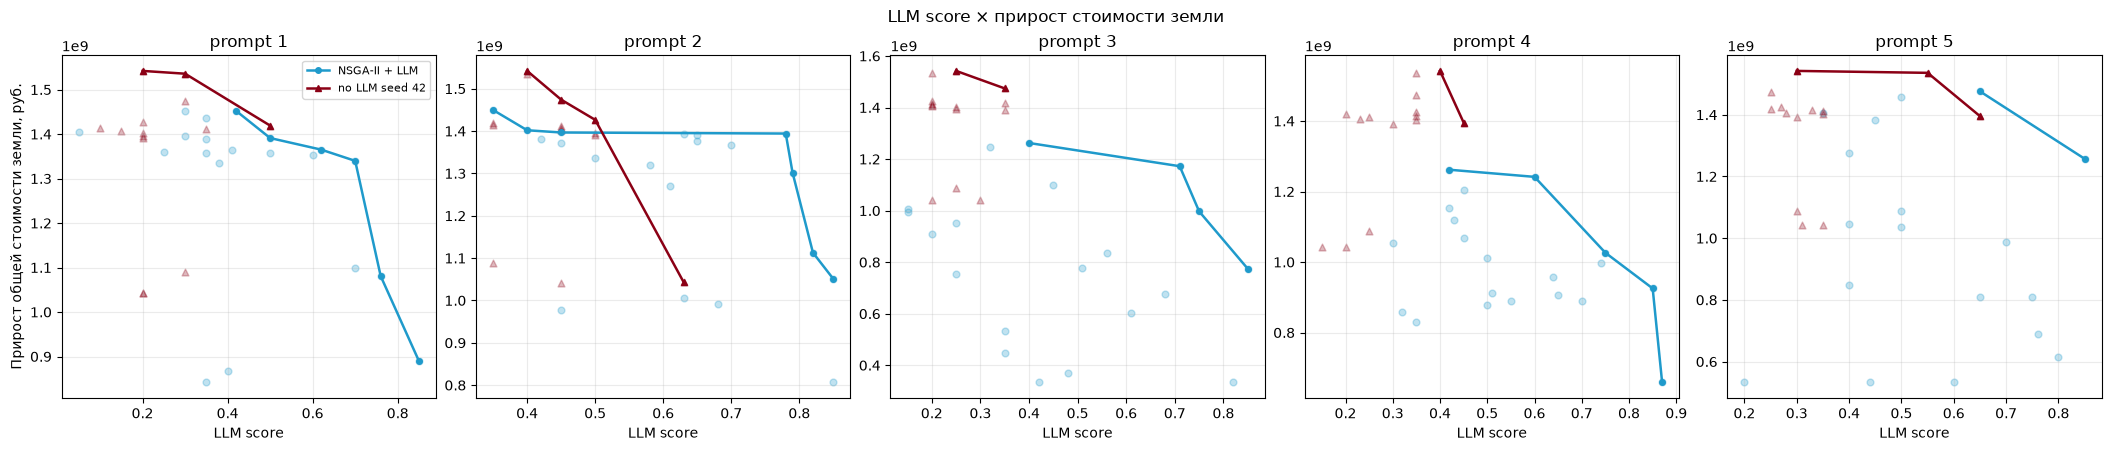

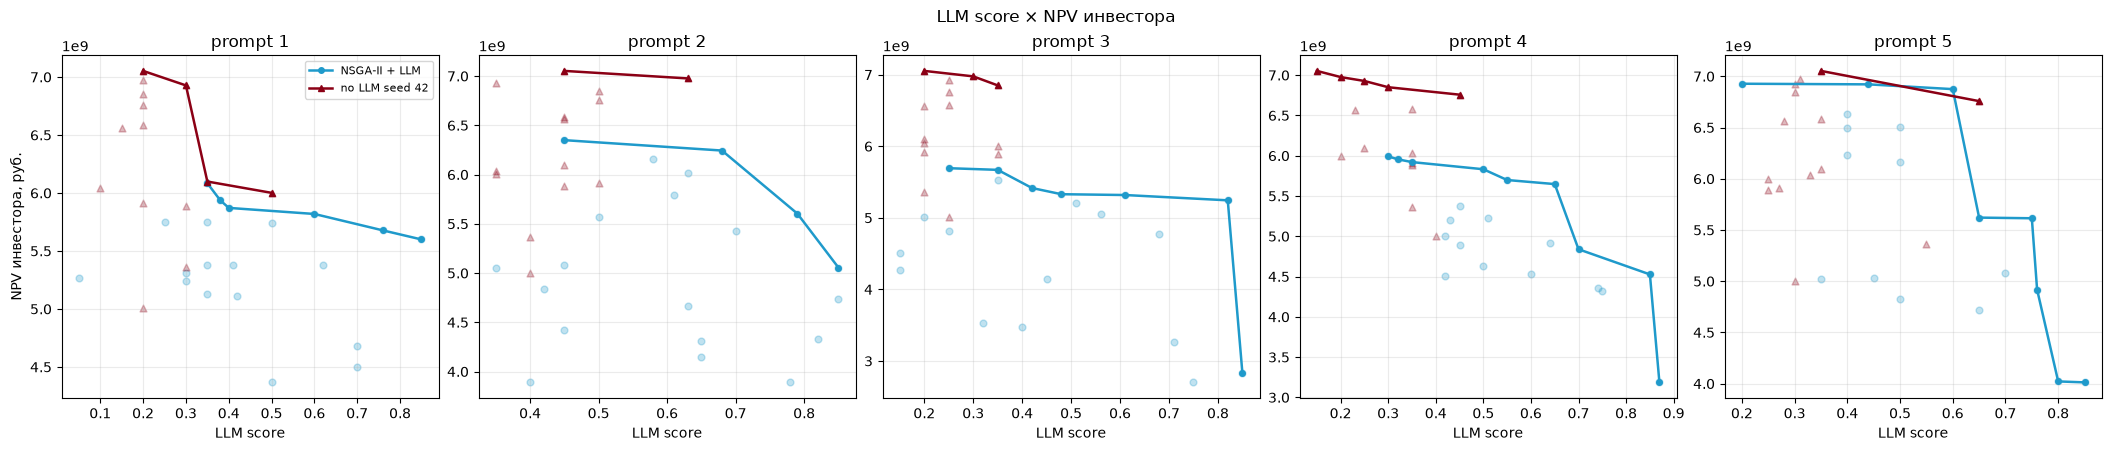

In [15]:
if "scored_seed42" not in globals():
    scored_seed42 = {
        prompt_id: read_jsonl(prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl")
        for prompt_id in prompt_fronts
        if (prompt_dir / f"prompt_{prompt_id}" / f"seed_{SEED}_scored_pareto_front.jsonl").exists()
    }


def nondominated(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    keep = []
    for i, p in enumerate(points):
        others = np.delete(points, i, axis=0)
        keep.append(not np.any(np.all(others >= p, axis=1) & np.any(others > p, axis=1)))
    return points[keep]


def hypervolume_2d(points, reference):
    front = np.array(sorted(nondominated(points), key=lambda p: p[0]))
    hv = 0.0
    prev_x = reference[0]
    for x, y in front:
        hv += max(0.0, x - prev_x) * max(0.0, y - reference[1])
        prev_x = max(prev_x, x)
    return hv, front


def hypervolume_3d(points, reference):
    front = nondominated(points)
    xs = np.unique(np.r_[reference[0], front[:, 0]])
    ys = np.unique(np.r_[reference[1], front[:, 1]])
    zs = np.unique(np.r_[reference[2], front[:, 2]])
    hv = 0.0
    for x0, x1 in zip(xs[:-1], xs[1:]):
        for y0, y1 in zip(ys[:-1], ys[1:]):
            for z0, z1 in zip(zs[:-1], zs[1:]):
                if np.any(np.all(front >= [x1, y1, z1], axis=1)):
                    hv += (x1 - x0) * (y1 - y0) * (z1 - z0)
    return hv, front


def prep_3crit(df, label):
    out = df.copy()
    out["algorithm"] = label
    out["llm_score"] = pd.to_numeric(out["llm score"], errors="coerce")
    out["investor_npv"] = pd.to_numeric(out["investor_npv"], errors="coerce")
    out["land_value_gain"] = pd.to_numeric(out["land_value_gain"], errors="coerce")
    return out.dropna(subset=["llm_score", "investor_npv", "land_value_gain"])


def reference_for(df, columns, min_margin):
    values = df[list(columns)].to_numpy(float)
    margin = np.maximum(np.ptp(values, axis=0) * 0.01, min_margin)
    return values.min(axis=0) - margin

projection_specs = [
    ("LLM score × прирост стоимости земли", ["llm_score", "land_value_gain"], [0.01, 1.0], "LLM score", "Прирост общей стоимости земли, руб."),
    ("LLM score × NPV инвестора", ["llm_score", "investor_npv"], [0.01, 1.0], "LLM score", "NPV инвестора, руб."),
]

rows = []
projection_fronts = {}
fronts_by_prompt = {}

for prompt_id in sorted(prompt_fronts):
    if prompt_id not in scored_seed42:
        continue

    llm_label = f"NSGA-II + LLM"
    no_llm_label = f"no LLM seed {SEED}"
    fronts_3crit = pd.concat(
        [
            prep_3crit(prompt_fronts[prompt_id], llm_label),
            prep_3crit(scored_seed42[prompt_id], no_llm_label),
        ],
        ignore_index=True,
    )
    fronts_by_prompt[prompt_id] = fronts_3crit

    for metric, cols, min_margin, _, _ in projection_specs:
        reference = reference_for(fronts_3crit, cols, min_margin)
        all_values = fronts_3crit[cols].to_numpy(float)
        norm = np.prod(all_values.max(axis=0) - reference)
        for algorithm, df in fronts_3crit.groupby("algorithm"):
            hv, front = hypervolume_2d(df[cols].to_numpy(float), reference)
            projection_fronts[(prompt_id, metric, algorithm)] = front
            rows.append({
                "prompt_id": prompt_id,
                "metric": metric,
                "algorithm": algorithm,
                "n_solutions": len(df),
                "n_front": len(front),
                "hypervolume": hv,
                "hypervolume_norm": hv / norm,
            })

    cols_3d = ["llm_score", "land_value_gain", "investor_npv"]
    reference_3d = reference_for(fronts_3crit, cols_3d, [0.01, 1.0, 1.0])
    points_3d = fronts_3crit[cols_3d].to_numpy(float)
    norm_3d = np.prod(points_3d.max(axis=0) - reference_3d)
    for algorithm, df in fronts_3crit.groupby("algorithm"):
        hv, front = hypervolume_3d(df[cols_3d].to_numpy(float), reference_3d)
        rows.append({
            "prompt_id": prompt_id,
            "metric": "3D: LLM score × прирост земли × NPV",
            "algorithm": algorithm,
            "n_solutions": len(df),
            "n_front": len(front),
            "hypervolume": hv,
            "hypervolume_norm": hv / norm_3d,
        })

hypervolume_by_prompt_3crit = pd.DataFrame(rows)
display(hypervolume_by_prompt_3crit)

for metric, cols, _, xlabel, ylabel in projection_specs:
    fig, axes = plt.subplots(1, len(fronts_by_prompt), figsize=(4.2 * len(fronts_by_prompt), 4.4), sharey=False, constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, prompt_id in zip(axes, sorted(fronts_by_prompt)):
        df_prompt = fronts_by_prompt[prompt_id]
        for algorithm, color, marker in [("NSGA-II + LLM", "#1f9acb", "o"), (f"no LLM seed {SEED}", "#8b0015", "^")]:
            df = df_prompt[df_prompt["algorithm"] == algorithm]
            ax.scatter(df[cols[0]], df[cols[1]], s=24, color=color, marker=marker, alpha=0.28)
            front = projection_fronts[(prompt_id, metric, algorithm)]
            ax.plot(front[:, 0], front[:, 1], color=color, marker=marker, lw=1.8, ms=4, label=algorithm)
        ax.set_title(f"prompt {prompt_id}")
        ax.set_xlabel(xlabel)
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel(ylabel)
    axes[0].legend(fontsize=8)
    fig.suptitle(metric)
    plt.show()


def front_polygon_2d(front, reference):
    front = np.asarray(front, dtype=float)
    if len(front) == 0:
        return np.empty((0, 2))
    if np.linalg.norm(front[-1] - reference) < np.linalg.norm(front[0] - reference):
        front = front[::-1]
    return np.vstack([reference, front, reference])


def xy_front(df):
    out = df[["investor_npv", "land_value_gain"]].copy()
    out["investor_npv"] = pd.to_numeric(out["investor_npv"], errors="coerce")
    out["land_value_gain"] = pd.to_numeric(out["land_value_gain"], errors="coerce")
    return out.dropna(subset=["investor_npv", "land_value_gain"])


def running_hv(log_path, reference):
    raw = pd.read_json(log_path, lines=True)
    df = xy_front(raw)
    df["eval_id"] = raw.loc[df.index, "eval_id"].to_numpy() if "eval_id" in raw.columns else np.arange(len(df))
    df = df.sort_values("eval_id")
    seen = []
    rows = []
    for _, row in df.iterrows():
        seen.append([row["investor_npv"], row["land_value_gain"]])
        hv, _ = hypervolume_2d(seen, reference)
        rows.append({"eval_id": row["eval_id"], "hypervolume_2d": hv})
    return pd.DataFrame(rows)

xy_rows = []
xy_front_lines = {}
xy_references = {}

for prompt_id in sorted(fronts_by_prompt):
    llm_front_xy = xy_front(prompt_fronts[prompt_id])
    no_llm_front_xy = xy_front(scored_seed42[prompt_id])
    points_all = pd.concat([llm_front_xy, no_llm_front_xy], ignore_index=True)[["investor_npv", "land_value_gain"]].to_numpy(float)
    reference = points_all.min(axis=0)
    xy_references[prompt_id] = reference
    norm = np.prod(points_all.max(axis=0) - reference)

    for algorithm, df in [("NSGA-II + LLM", llm_front_xy), (f"no LLM seed {SEED}", no_llm_front_xy)]:
        hv, front = hypervolume_2d(df[["investor_npv", "land_value_gain"]].to_numpy(float), reference)
        xy_front_lines[(prompt_id, algorithm)] = front
        xy_rows.append({
            "prompt_id": prompt_id,
            "algorithm": algorithm,
            "n_solutions": len(df),
            "n_front": len(front),
            "hypervolume_2d": hv,
            "hypervolume_2d_norm": hv / norm,
            "reference_investor_npv": reference[0],
            "reference_land_value_gain": reference[1],
        })

xy_hypervolume_by_prompt = pd.DataFrame(xy_rows)
display(xy_hypervolume_by_prompt)

colors = {"NSGA-II + LLM": "#1f9acb", f"no LLM seed {SEED}": "#8b0015"}
fig, axes = plt.subplots(1, len(fronts_by_prompt), figsize=(4.4 * len(fronts_by_prompt), 4.6), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, prompt_id in zip(axes, sorted(fronts_by_prompt)):
    reference = xy_references[prompt_id]
    for algorithm in ["NSGA-II + LLM", f"no LLM seed {SEED}"]:
        front = xy_front_lines[(prompt_id, algorithm)]
        polygon = front_polygon_2d(front, reference)
        ax.fill(polygon[:, 0], polygon[:, 1], facecolor=colors[algorithm], edgecolor=colors[algorithm], linewidth=1.8, alpha=0.14)
        ax.plot(polygon[:, 0], polygon[:, 1], color=colors[algorithm], lw=1.8)
        ax.scatter(front[:, 0], front[:, 1], s=34, color=colors[algorithm], edgecolor="white", linewidth=0.6, label=algorithm)
    ax.scatter(reference[0], reference[1], marker="*", s=130, c="black", zorder=5)
    ax.set_title(f"prompt {prompt_id}")
    ax.set_xlabel("NPV инвестора, руб.")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Прирост общей стоимости земли, руб.")
axes[0].legend(fontsize=8)
fig.suptitle("Сравнение Парето-фронтов: 2D hypervolume")
plt.show()

no_llm_log_path = no_llm_dir / f"no_llm_optimization_log_{SEED}.jsonl"
fig, axes = plt.subplots(1, len(fronts_by_prompt), figsize=(4.4 * len(fronts_by_prompt), 4.2), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, prompt_id in zip(axes, sorted(fronts_by_prompt)):
    reference = xy_references[prompt_id]
    llm_log_path = prompt_dir / f"prompt_{prompt_id}" / f"prompt_{prompt_id}_optimization_log.jsonl"
    running = {
        "NSGA-II + LLM": running_hv(llm_log_path, reference),
        f"no LLM seed {SEED}": running_hv(no_llm_log_path, reference),
    }
    for algorithm, df in running.items():
        ax.plot(df["eval_id"], df["hypervolume_2d"], color=colors[algorithm], label=algorithm)
    ax.set_title(f"prompt {prompt_id}")
    ax.set_xlabel("Оценка решения, eval_id")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Накопленный 2D hypervolume")
axes[0].legend(fontsize=8)
fig.suptitle("Сходимость по hypervolume")
plt.show()


,S,scenario_id,investor_npv,land_value_gain,llm score
0,S1,no_llm_pareto_front_42_1,0.000000,1.000000,0.250
1,S2,no_llm_pareto_front_42_2,0.534148,0.739166,0.625
2,S3,no_llm_pareto_front_42_3,0.938893,0.093534,0.500
3,S4,no_llm_pareto_front_42_4,0.962733,0.001568,0.250
4,S5,no_llm_pareto_front_42_5,0.486485,0.753924,1.000
5,S6,no_llm_pareto_front_42_6,0.504944,0.743912,0.000
6,S7,no_llm_pareto_front_42_7,0.443844,0.768753,0.250
7,S8,no_llm_pareto_front_42_8,0.770421,0.721066,0.250
8,S9,no_llm_pareto_front_42_9,0.855936,0.706618,0.250
9,S10,no_llm_pareto_front_42_10,0.760856,0.729124,0.125


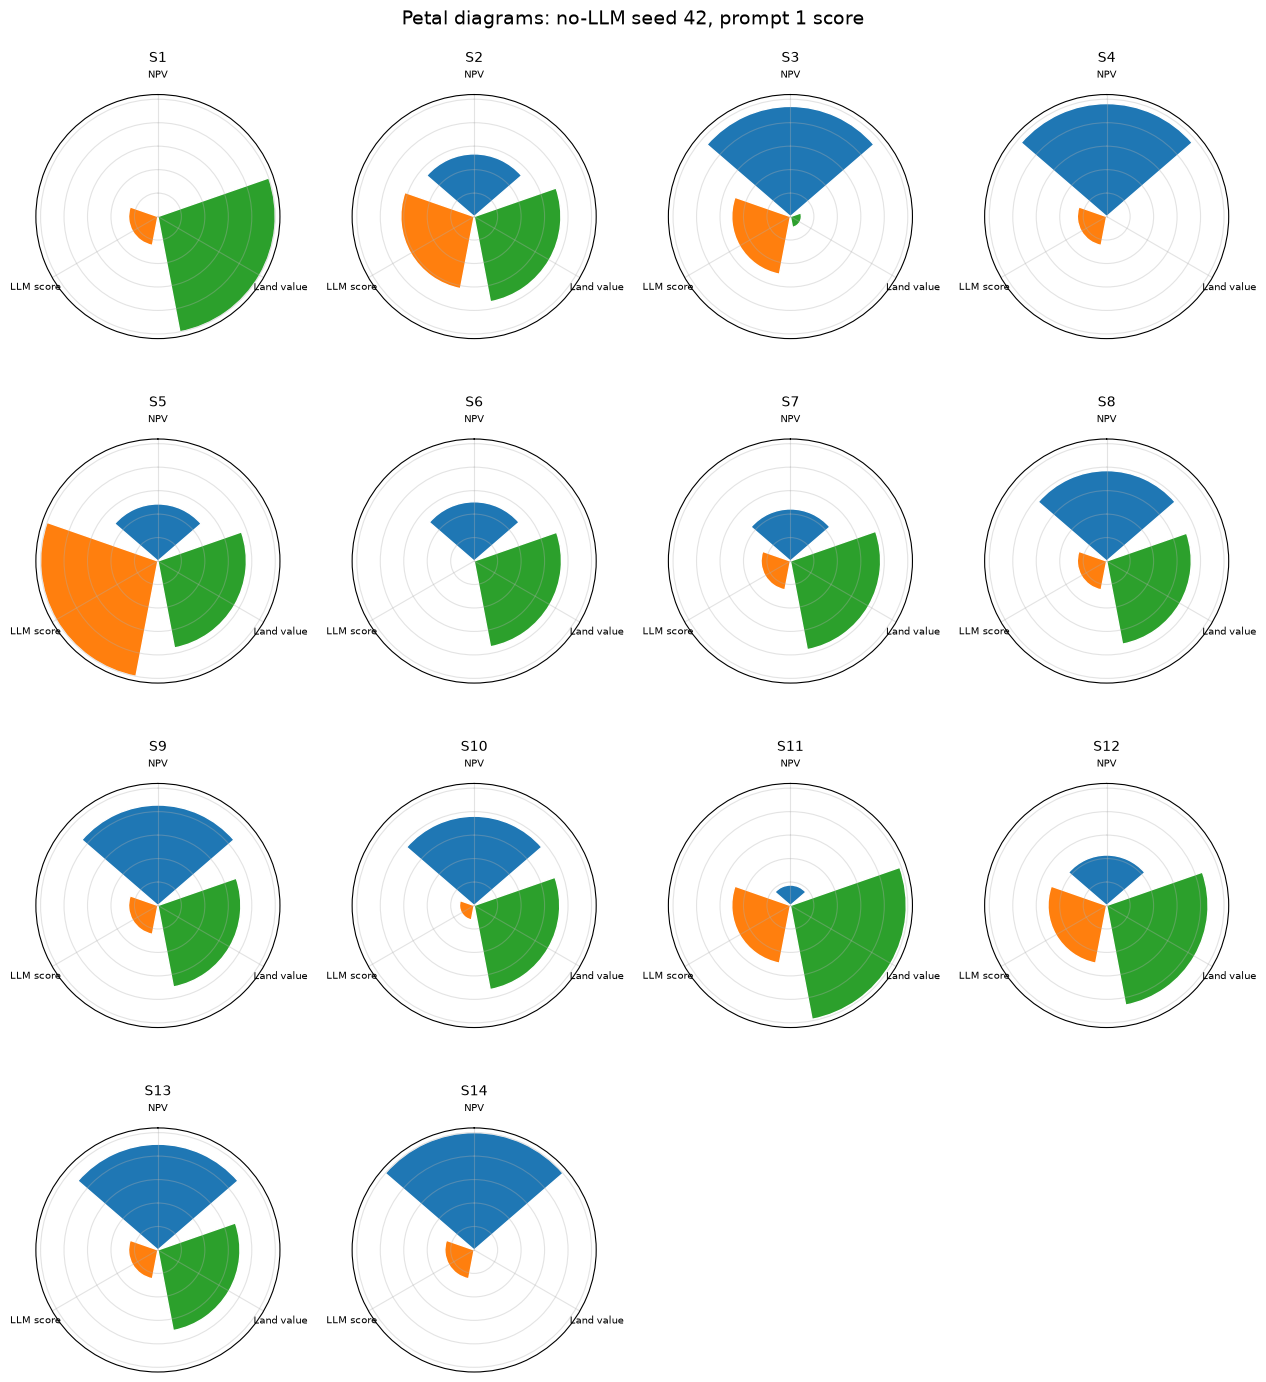

In [16]:
import math

objective_cols = ["investor_npv", "land_value_gain", "llm score"]
objective_labels = ["NPV", "Land value", "LLM score"]
objective_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

petal_source = scored_seed42[1].copy()
for col in objective_cols:
    petal_source[col] = pd.to_numeric(petal_source[col], errors="coerce")
petal_source = petal_source.dropna(subset=objective_cols).reset_index(drop=True)

mins = petal_source[objective_cols].min()
ranges = (petal_source[objective_cols].max() - mins).replace(0, np.nan)
petal_norm = ((petal_source[objective_cols] - mins) / ranges).fillna(0.0).clip(0, 1)
petal_scores = petal_source[["scenario_id"]].join(petal_norm)
petal_scores.insert(0, "S", [f"S{i + 1}" for i in range(len(petal_scores))])
display(petal_scores)


def draw_petal(ax, values):
    theta = np.linspace(0, 2 * np.pi, len(values), endpoint=False)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.bar(theta, values, width=2 * np.pi / len(values) * 0.82, color=objective_colors, edgecolor="white")
    ax.set_ylim(0, 1.04)
    ax.set_xticks(theta)
    ax.set_xticklabels(objective_labels, fontsize=7)
    ax.set_yticklabels([])
    ax.grid(True, alpha=0.35)

n = len(petal_scores)
ncols = min(4, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.6 * nrows), subplot_kw={"projection": "polar"})
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, petal_scores.iterrows()):
    draw_petal(ax, row[objective_cols].to_numpy(float))
    ax.set_title(row["S"], fontsize=10)
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f"Petal diagrams: no-LLM seed {SEED}, prompt 1 score", fontsize=14)
fig.tight_layout()
plt.show()
